# Chronic Kidney Disease (CKD) KNN Starter Notebook

This notebook demonstrates a basic end-to-end workflow for a KNN classifier that predicts CKD from a CSV dataset.

In [7]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

project_root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.preprocessing import clean_ckd_dataframe, load_dataset, prepare_features_and_target

In [ ]:
dataset_path = project_root / 'data' / 'raw' / 'Sec001_ckd_dataset_v2.csv'
if not dataset_path.exists():
    raise FileNotFoundError(
        f'Missing dataset: {dataset_path}. Expected data/raw/Sec001_ckd_dataset_v2.csv.'
    )

raw_df = load_dataset(dataset_path)

# Normalize target naming across dataset variants
if 'classification' not in raw_df.columns and 'class' in raw_df.columns:
    raw_df = raw_df.rename(columns={'class': 'classification'})

# Drop top non-data rows from the CKD file
raw_df = raw_df.iloc[2:].copy()

# Reset index after dropping junk rows
raw_df = raw_df.reset_index(drop=True)

raw_df.head()



In [9]:
clean_df = clean_ckd_dataframe(raw_df)

# Force all non-target columns to numeric
for col in clean_df.columns:
    if col != 'classification':
        clean_df[col] = pd.to_numeric(clean_df[col], errors='coerce')

# Keep only valid CKD labels
clean_df = clean_df.copy()
clean_df['classification'] = clean_df['classification'].astype(str).str.strip().str.lower()
clean_df = clean_df[clean_df['classification'].isin(['ckd', 'notckd'])]

# Drop columns that are entirely missing
clean_df = clean_df.dropna(axis=1, how='all')

print(clean_df.head())
print("Shape:", clean_df.shape)
print("Nulls:", clean_df.isna().sum().sort_values(ascending=False).head(10))
print(clean_df['classification'].value_counts())

   bp (Diastolic)  bp limit classification  rbc  pc  pcc  ba  htn  dm  cad  \
0               0         0            ckd    0   0    0   0    0   0    0   
1               0         0            ckd    0   0    0   0    0   0    0   
2               0         0            ckd    1   1    0   1    0   0    0   
3               1         1            ckd    0   0    0   0    0   0    0   
4               0         0            ckd    0   0    0   0    0   1    0   

   appet  pe  ane  affected  
0      0   0    0         1  
1      0   0    0         1  
2      1   0    0         1  
3      0   0    0         1  
4      1   1    0         1  
Shape: (200, 14)
Nulls: bp (Diastolic)    0
bp limit          0
classification    0
rbc               0
pc                0
pcc               0
ba                0
htn               0
dm                0
cad               0
dtype: int64
classification
ckd       128
notckd     72
Name: count, dtype: int64


In [10]:
#print(clean_df['classification'].head(10))
#print(clean_df['classification'].unique()[:10])
#print(clean_df['classification'].value_counts())

In [11]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X, y = prepare_features_and_target(clean_df, target_col='classification')

print("X shape:", X.shape)
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("Best params:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

X shape: (200, 13)
classification
1    128
0     72
Name: count, dtype: int64
Best params: {'knn__metric': 'euclidean', 'knn__n_neighbors': 3, 'knn__weights': 'uniform'}
Best CV score: 1.0


Test accuracy: 1.000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        26

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



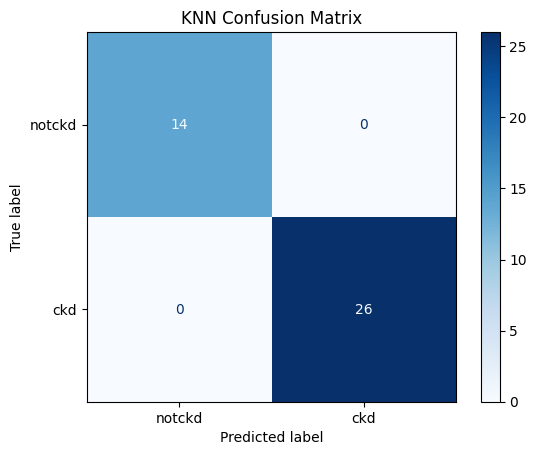

In [13]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Test accuracy: {accuracy:.3f}")
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['notckd', 'ckd'],
    cmap='Blues'
)
plt.title('KNN Confusion Matrix')
plt.show()

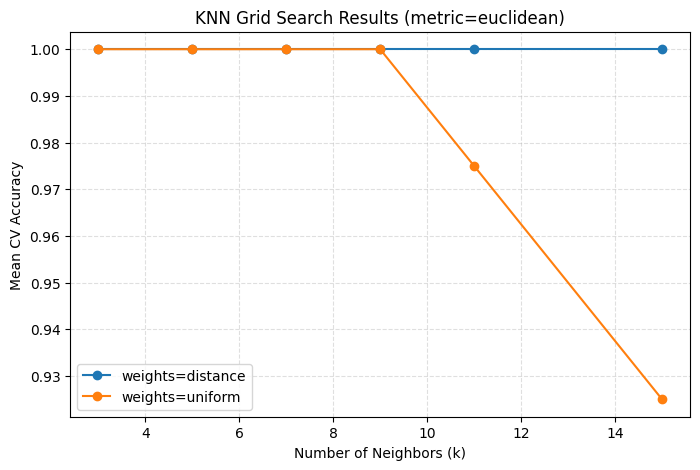

In [15]:
results = pd.DataFrame(grid_search.cv_results_)
results['n_neighbors'] = results['param_knn__n_neighbors'].astype(int)
results['weights'] = results['param_knn__weights'].astype(str)
results['metric'] = results['param_knn__metric'].astype(str)

plot_df = results[results['metric'] == 'euclidean']

plt.figure(figsize=(8, 5))
for weight, grp in plot_df.groupby('weights'):
    grp = grp.sort_values('n_neighbors')
    plt.plot(
        grp['n_neighbors'],
        grp['mean_test_score'],
        marker='o',
        label=f'weights={weight}'
    )

plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean CV Accuracy')
plt.title('KNN Grid Search Results (metric=euclidean)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()